In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score , classification_report , confusion_matrix
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv("income_evaluation.csv")

In [3]:
df.head(10)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
5,37,Private,284582,Masters,14,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40,United-States,<=50K
6,49,Private,160187,9th,5,Married-spouse-absent,Other-service,Not-in-family,Black,Female,0,0,16,Jamaica,<=50K
7,52,Self-emp-not-inc,209642,HS-grad,9,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,45,United-States,>50K
8,31,Private,45781,Masters,14,Never-married,Prof-specialty,Not-in-family,White,Female,14084,0,50,United-States,>50K
9,42,Private,159449,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,5178,0,40,United-States,>50K


In [4]:
df.shape

(32561, 15)

In [5]:
df.columns

Index(['age', ' workclass', ' fnlwgt', ' education', ' education-num',
       ' marital-status', ' occupation', ' relationship', ' race', ' sex',
       ' capital-gain', ' capital-loss', ' hours-per-week', ' native-country',
       ' income'],
      dtype='str')

In [6]:
col_names = ["age","workclass","finalweight","education","education_num","marital_status","occupation",
             "relationship","race","sex","capital_gain","capital_loss","hours_per_week","native_country","income"]

In [7]:
df.columns = col_names

In [8]:
df.columns

Index(['age', 'workclass', 'finalweight', 'education', 'education_num',
       'marital_status', 'occupation', 'relationship', 'race', 'sex',
       'capital_gain', 'capital_loss', 'hours_per_week', 'native_country',
       'income'],
      dtype='str')

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       32561 non-null  str  
 2   finalweight     32561 non-null  int64
 3   education       32561 non-null  str  
 4   education_num   32561 non-null  int64
 5   marital_status  32561 non-null  str  
 6   occupation      32561 non-null  str  
 7   relationship    32561 non-null  str  
 8   race            32561 non-null  str  
 9   sex             32561 non-null  str  
 10  capital_gain    32561 non-null  int64
 11  capital_loss    32561 non-null  int64
 12  hours_per_week  32561 non-null  int64
 13  native_country  32561 non-null  str  
 14  income          32561 non-null  str  
dtypes: int64(6), str(9)
memory usage: 3.7 MB


In [10]:
df.describe()

,age,finalweight,education_num,capital_gain,capital_loss,hours_per_week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [11]:
df.isnull().sum()

age               0
workclass         0
finalweight       0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
dtype: int64

In [12]:
for col in df.columns:
    if df[col].dtype == "str":
        print(col)


workclass
education
marital_status
occupation
relationship
race
sex
native_country
income


In [13]:
for col in df.columns:
    if df[col].dtype == "int64":
        print(col)

age
finalweight
education_num
capital_gain
capital_loss
hours_per_week


In [15]:
categorical = [col for col in df.columns if df[col].dtype == "str"]
numerical = [col for col in df.columns if df[col].dtype == "int64"]

In [16]:
categorical

['workclass',
 'education',
 'marital_status',
 'occupation',
 'relationship',
 'race',
 'sex',
 'native_country',
 'income']

In [17]:
numerical

['age',
 'finalweight',
 'education_num',
 'capital_gain',
 'capital_loss',
 'hours_per_week']

In [18]:
df[categorical].head()

,workclass,education,marital_status,occupation,relationship,race,sex,native_country,income
0,State-gov,Bachelors,Never-married,Adm-clerical,Not-in-family,White,Male,United-States,<=50K
1,Self-emp-not-inc,Bachelors,Married-civ-spouse,Exec-managerial,Husband,White,Male,United-States,<=50K
2,Private,HS-grad,Divorced,Handlers-cleaners,Not-in-family,White,Male,United-States,<=50K
3,Private,11th,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,United-States,<=50K
4,Private,Bachelors,Married-civ-spouse,Prof-specialty,Wife,Black,Female,Cuba,<=50K


In [19]:
df["income"].value_counts()

income
<=50K    24720
>50K      7841
Name: count, dtype: int64

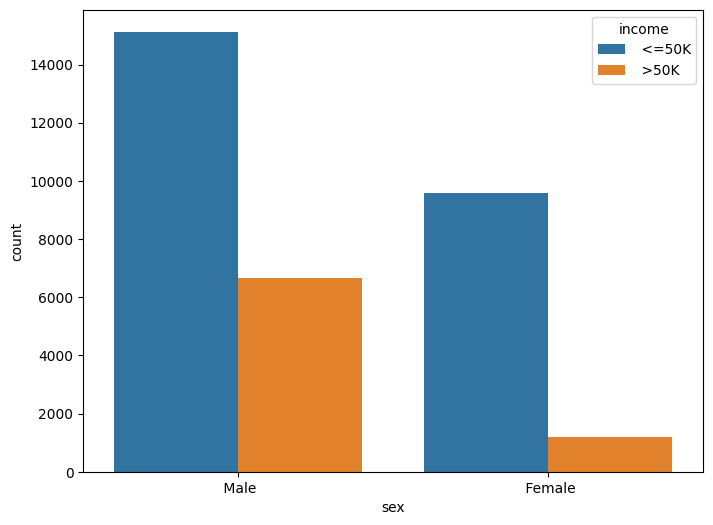

In [21]:
fig , ax = plt.subplots(figsize = (8,6))
ax = sns.countplot(x=df["sex"] , hue=df["income"] , data=df)
plt.show()

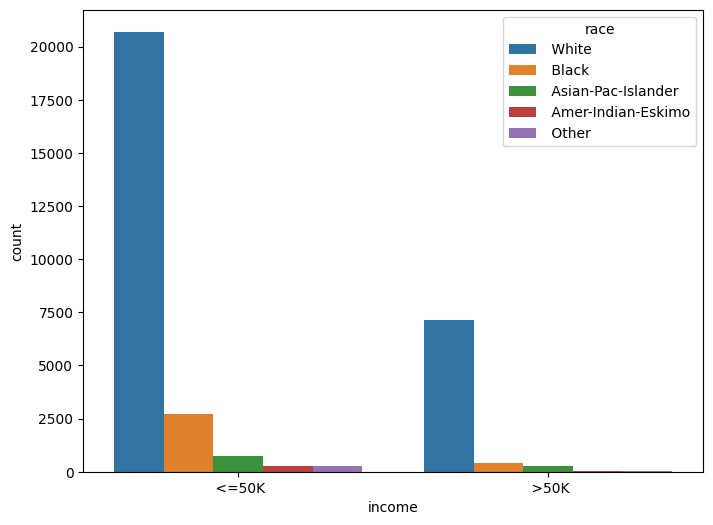

In [22]:
fig , ax = plt.subplots(figsize=(8,6))
ax = sns.countplot(x = df["income"] , data = df , hue = df["race"])
plt.show()

In [23]:
df["workclass"].value_counts()

workclass
Private             22696
Self-emp-not-inc     2541
Local-gov            2093
?                    1836
State-gov            1298
Self-emp-inc         1116
Federal-gov           960
Without-pay            14
Never-worked            7
Name: count, dtype: int64

In [24]:
df["workclass"].unique()

<StringArray>
[       ' State-gov', ' Self-emp-not-inc',          ' Private',
      ' Federal-gov',        ' Local-gov',                ' ?',
     ' Self-emp-inc',      ' Without-pay',     ' Never-worked']
Length: 9, dtype: str

In [25]:
df["workclass"] = df["workclass"].replace(" ?",np.nan)

In [26]:
df["workclass"].unique()

<StringArray>
[       ' State-gov', ' Self-emp-not-inc',          ' Private',
      ' Federal-gov',        ' Local-gov',                 nan,
     ' Self-emp-inc',      ' Without-pay',     ' Never-worked']
Length: 9, dtype: str

In [27]:
df["workclass"].value_counts()

workclass
Private             22696
Self-emp-not-inc     2541
Local-gov            2093
State-gov            1298
Self-emp-inc         1116
Federal-gov           960
Without-pay            14
Never-worked            7
Name: count, dtype: int64

In [28]:
df["occupation"].value_counts()

occupation
Prof-specialty       4140
Craft-repair         4099
Exec-managerial      4066
Adm-clerical         3770
Sales                3650
Other-service        3295
Machine-op-inspct    2002
?                    1843
Transport-moving     1597
Handlers-cleaners    1370
Farming-fishing       994
Tech-support          928
Protective-serv       649
Priv-house-serv       149
Armed-Forces            9
Name: count, dtype: int64

In [29]:
df["occupation"].unique()

<StringArray>
[     ' Adm-clerical',   ' Exec-managerial', ' Handlers-cleaners',
    ' Prof-specialty',     ' Other-service',             ' Sales',
      ' Craft-repair',  ' Transport-moving',   ' Farming-fishing',
 ' Machine-op-inspct',      ' Tech-support',                 ' ?',
   ' Protective-serv',      ' Armed-Forces',   ' Priv-house-serv']
Length: 15, dtype: str

In [30]:
df["occupation"] = df["occupation"].replace(" ?",np.nan)

In [31]:
df["occupation"].value_counts()

occupation
Prof-specialty       4140
Craft-repair         4099
Exec-managerial      4066
Adm-clerical         3770
Sales                3650
Other-service        3295
Machine-op-inspct    2002
Transport-moving     1597
Handlers-cleaners    1370
Farming-fishing       994
Tech-support          928
Protective-serv       649
Priv-house-serv       149
Armed-Forces            9
Name: count, dtype: int64

In [32]:
df["native_country"].value_counts()

native_country
United-States                 29170
Mexico                          643
?                               583
Philippines                     198
Germany                         137
Canada                          121
Puerto-Rico                     114
El-Salvador                     106
India                           100
Cuba                             95
England                          90
Jamaica                          81
South                            80
China                            75
Italy                            73
Dominican-Republic               70
Vietnam                          67
Guatemala                        64
Japan                            62
Poland                           60
Columbia                         59
Taiwan                           51
Haiti                            44
Iran                             43
Portugal                         37
Nicaragua                        34
Peru                             31
France       

In [33]:
df["native_country"].unique()

<StringArray>
[             ' United-States',                       ' Cuba',
                    ' Jamaica',                      ' India',
                          ' ?',                     ' Mexico',
                      ' South',                ' Puerto-Rico',
                   ' Honduras',                    ' England',
                     ' Canada',                    ' Germany',
                       ' Iran',                ' Philippines',
                      ' Italy',                     ' Poland',
                   ' Columbia',                   ' Cambodia',
                   ' Thailand',                    ' Ecuador',
                       ' Laos',                     ' Taiwan',
                      ' Haiti',                   ' Portugal',
         ' Dominican-Republic',                ' El-Salvador',
                     ' France',                  ' Guatemala',
                      ' China',                      ' Japan',
                 ' Yugoslavia',          

In [34]:
df["native_country"] = df["native_country"].replace(" ?",np.nan)

In [35]:
df["native_country"].unique()

<StringArray>
[             ' United-States',                       ' Cuba',
                    ' Jamaica',                      ' India',
                           nan,                     ' Mexico',
                      ' South',                ' Puerto-Rico',
                   ' Honduras',                    ' England',
                     ' Canada',                    ' Germany',
                       ' Iran',                ' Philippines',
                      ' Italy',                     ' Poland',
                   ' Columbia',                   ' Cambodia',
                   ' Thailand',                    ' Ecuador',
                       ' Laos',                     ' Taiwan',
                      ' Haiti',                   ' Portugal',
         ' Dominican-Republic',                ' El-Salvador',
                     ' France',                  ' Guatemala',
                      ' China',                      ' Japan',
                 ' Yugoslavia',          

In [36]:
df.isnull().sum()

age                  0
workclass         1836
finalweight          0
education            0
education_num        0
marital_status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital_gain         0
capital_loss         0
hours_per_week       0
native_country     583
income               0
dtype: int64

In [37]:
X = df.drop("income",axis=1)
y = df["income"]

In [38]:
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size = 0.25 , random_state = 42)

In [39]:
categorical = [col for col in X_train.columns if X_train[col].dtype == "str"]

In [40]:
X_train[categorical].isnull().sum()

workclass         1360
education            0
marital_status       0
occupation        1367
relationship         0
race                 0
sex                  0
native_country     435
dtype: int64

In [41]:
X_test[categorical].isnull().sum()

workclass         476
education           0
marital_status      0
occupation        476
relationship        0
race                0
sex                 0
native_country    148
dtype: int64

In [42]:
X_train["workclass"].mode()

0     Private
Name: workclass, dtype: str

In [45]:
X_train["workclass"].mode()[0]

' Private'

In [46]:
X_train["workclass"] = X_train["workclass"].fillna(X_train["workclass"].mode()[0])
X_test["occupation"] = X_test["occupation"].fillna(X_test["occupation"].mode()[0])
X_test["workclass"] = X_test["workclass"].fillna(X_test["workclass"].mode()[0])
X_train["occupation"] = X_train["occupation"].fillna(X_train["occupation"].mode()[0])
X_train["native_country"] = X_train["native_country"].fillna(X_train["native_country"].mode()[0])
X_test["native_country"] = X_test["native_country"].fillna(X_test["native_country"].mode()[0])


In [47]:
X_train.isnull().sum()

age               0
workclass         0
finalweight       0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
dtype: int64

In [48]:
X_test.isnull().sum()

age               0
workclass         0
finalweight       0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
dtype: int64

In [49]:
from sklearn.preprocessing import LabelEncoder , OneHotEncoder

In [50]:
label = LabelEncoder()

In [51]:
y_train = label.fit_transform(y_train)
y_test = label.transform(y_test)

In [52]:
categorical

['workclass',
 'education',
 'marital_status',
 'occupation',
 'relationship',
 'race',
 'sex',
 'native_country']

In [55]:
one_hot_categories = ['workclass',
 'education',
 'marital_status',
 'occupation',
 'relationship',
 'race',
 'sex',
 'native_country']

In [56]:
encoder = OneHotEncoder(handle_unknown="ignore",sparse_output=False)

In [57]:
X_train_encoded = encoder.fit_transform(X_train[one_hot_categories])
X_test_encoded = encoder.transform(X_test[one_hot_categories])

In [60]:
X_train_final = pd.concat([X_train.drop(columns = one_hot_categories) , pd.DataFrame(X_train_encoded,index = X_train.index).add_prefix("enc_")] , axis = 1)
X_test_final = pd.concat([X_test.drop(columns = one_hot_categories) , pd.DataFrame(X_test_encoded , index = X_test.index).add_prefix("enc_")] , axis = 1)


In [61]:
X_train_final

,age,finalweight,education_num,capital_gain,capital_loss,hours_per_week,enc_0,enc_1,enc_2,enc_3,...,enc_89,enc_90,enc_91,enc_92,enc_93,enc_94,enc_95,enc_96,enc_97,enc_98
29,49,193366,9,0,0,40,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
12181,27,134152,9,0,0,45,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
18114,44,169980,7,0,0,60,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4278,59,656036,13,0,0,60,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
12050,54,188136,13,0,1408,38,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29802,47,359461,13,0,0,40,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
5390,31,147215,8,0,0,21,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
860,18,216284,7,0,0,20,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
15795,50,54261,9,0,0,84,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [62]:
from sklearn.ensemble import RandomForestClassifier

In [63]:
model = RandomForestClassifier()

In [64]:
params = {
    "max_depth": [5 , 8 , 20],
    "max_features": ["sqrt","log2",5],
    "n_estimators": [10,100,1000]
}

In [65]:
from sklearn.model_selection import GridSearchCV

In [66]:
grid = GridSearchCV(estimator=RandomForestClassifier() , n_jobs = -1 ,param_grid = params)

In [67]:
grid.fit(X_train_final,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 8, ...], 'max_features': ['sqrt', 'log2', ...], 'n_estimators': [10, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 

In [68]:
y_pred = grid.predict(X_test_final)

In [69]:
accuracy_score(y_test,y_pred)

0.8673381648446137

In [70]:
grid.best_params_

{'max_depth': 20, 'max_features': 'sqrt', 'n_estimators': 1000}